In [1]:
%load_ext autoreload
%autoreload 2

## Baseline Forecasting Models

This notebook establishes baseline forecasting models for
daily Fremont Bridge bicycle traffic. These simple models
serve as performance benchmarks that more advanced
forecasting methods must outperform.

The notebook compares multiple baseline forecasting
strategies using standard forecasting error metrics.

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

from src.evaluation.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    mean_absolute_percentage_error,
)

### Load Modeling Dataset

The processed forecasting dataset is loaded from the
`data/processed` directory. This dataset contains the
daily bicycle traffic observations, weather variables,
and engineered forecasting features developed in the
previous phases of the project.

In [3]:
#Read in data
features_df = pd.read_csv(
    "../data/processed/bike_weather_features.csv"
)

features_df["date"] = pd.to_datetime(
    features_df["date"]
)

In [4]:
#Verify dataset
print(features_df.shape)

features_df.info()

features_df.head()

(4990, 15)
<class 'pandas.DataFrame'>
RangeIndex: 4990 entries, 0 to 4989
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   date             4990 non-null   datetime64[us]
 1   fremont_bridge   4990 non-null   float64       
 2   temperature_2m   4990 non-null   float64       
 3   precipitation    4990 non-null   float64       
 4   wind_speed_10m   4990 non-null   float64       
 5   day_of_week      4990 non-null   int64         
 6   month            4990 non-null   int64         
 7   year             4990 non-null   int64         
 8   day_of_year      4990 non-null   int64         
 9   month_name       4990 non-null   str           
 10  is_weekend       4990 non-null   int64         
 11  lag_1            4989 non-null   float64       
 12  lag_7            4983 non-null   float64       
 13  rolling_mean_7   4984 non-null   float64       
 14  rolling_mean_30  4961 non-null   float64

,date,fremont_bridge,temperature_2m,precipitation,wind_speed_10m,day_of_week,month,year,day_of_year,month_name,is_weekend,lag_1,lag_7,rolling_mean_7,rolling_mean_30
0,2012-10-02,1938.0,13.300000,0.0,5.654545,1,10,2012,276,October,0,NaN,NaN,NaN,NaN
1,2012-10-03,3521.0,11.495833,0.0,12.845833,2,10,2012,277,October,0,1938.0,NaN,NaN,NaN
2,2012-10-04,3475.0,11.750000,0.0,11.070833,3,10,2012,278,October,0,3521.0,NaN,NaN,NaN
3,2012-10-05,3148.0,12.079167,0.0,9.095833,4,10,2012,279,October,0,3475.0,NaN,NaN,NaN
4,2012-10-06,2006.0,12.454167,0.0,8.541667,5,10,2012,280,October,1,3148.0,NaN,NaN,NaN


### Train-Test Split

The forecasting dataset is divided chronologically into
training and testing sets. The training set contains the
earliest observations and is used to fit forecasting
models, while the testing set contains the most recent
observations and is reserved for evaluating predictive
performance on unseen data.

A chronological split is used instead of a random split
to prevent temporal data leakage and better simulate
real-world forecasting.

In [5]:
# Define the split date
split_date = "2024-06-01"

# Split chronologically
train_df = features_df[features_df["date"] < split_date].copy()

test_df = features_df[features_df["date"] >= split_date].copy()

In [6]:
#Validate data
print("Training Set")
print(train_df["date"].min())
print(train_df["date"].max())
print(train_df.shape)

print()

print("Testing Set")
print(test_df["date"].min())
print(test_df["date"].max())
print(test_df.shape)

Training Set
2012-10-02 00:00:00
2024-05-31 00:00:00
(4260, 15)

Testing Set
2024-06-01 00:00:00
2026-05-31 00:00:00
(730, 15)


### Visualize Train-Test Split

The chronological train-test split is visualized below.
The blue region represents the historical data used to
fit forecasting models, while the orange region
represents the unseen data reserved for evaluation.

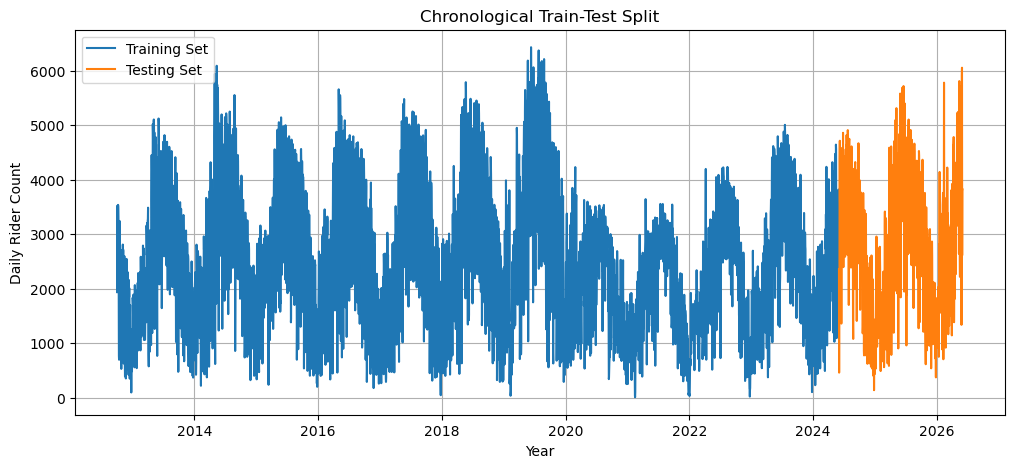

In [7]:
plt.figure(figsize=(12, 5))

plt.plot(
    train_df["date"],
    train_df["fremont_bridge"],
    label="Training Set"
)

plt.plot(
    test_df["date"],
    test_df["fremont_bridge"],
    label="Testing Set"
)

plt.xlabel("Year")
plt.ylabel("Daily Rider Count")
plt.title("Chronological Train-Test Split")
plt.legend()
plt.grid()

plt.show()

## Forecast Evaluation Metrics

Forecasting models are evaluated using quantitative error
metrics that compare predicted values with observed
bicycle traffic. These metrics provide objective measures
of predictive accuracy and allow different forecasting
models to be compared on a common basis.

The evaluation metrics are implemented as reusable
functions within the project source code and are applied
consistently throughout the remainder of the forecasting
pipeline.

In [11]:
# Example observations
y_true = [10, 20, 30, 40]

# Example predictions
y_pred = [12, 18, 31, 45]

mae = mean_absolute_error(y_true, y_pred)
rmse = root_mean_squared_error(y_true, y_pred)
mape = mean_absolute_percentage_error(y_true, y_pred)
print(f"MAE = {mae:.2f}")
print(f"RMSE = {rmse:.2f}")
print(f"MAPE = {mape:.2f}")

MAE = 2.50
RMSE = 2.92
MAPE = 11.46
